In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

In [2]:
# Load dataset

file_path = "online_purchase_predictor_data.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())
df.info()

Dataset shape: (100000, 16)


,UserID,BrowsingTime(min),Clicks,PagesVisited,AddToCart,Category,WishlistAdd,BounceRate(min),ExitPage,TimePerPage(min),UserType,Location,SearchKeywords,SessionDuration(min),ProductViews,Purchase
0,User043101,55.29,53.0,11.0,10.0,Electronics,Yes,1.38,Home,4.98,Returning,NaN,shoes,51.04,85.0,1.0
1,User037076,45.20,27.0,47.0,2.0,NaN,Yes,3.45,Search,0.35,Returning,Mumbai,shoes,49.65,67.0,0.0
2,User020848,7.42,11.0,32.0,9.0,Sports,No,1.35,NaN,3.27,New,Dehradun,novel,6.12,4.0,NaN
3,User013368,81.60,19.0,35.0,5.0,Clothing,Yes,2.82,Search,0.89,Returning,Bangalore,novel,81.89,81.0,1.0
4,User061998,103.99,84.0,27.0,7.0,Home,No,20.36,Home,4.97,New,Mumbai,phone,99.81,94.0,1.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   UserID                95024 non-null  object 
 1   BrowsingTime(min)     94929 non-null  float64
 2   Clicks                95030 non-null  float64
 3   PagesVisited          94863 non-null  float64
 4   AddToCart             95080 non-null  float64
 5   Category              94996 non-null  object 
 6   WishlistAdd           95078 non-null  object 
 7   BounceRate(min)       94970 non-null  float64
 8   ExitPage              95018 non-null  object 
 9   TimePerPage(min)      94911 non-null  float64
 10  UserType              94886 non-null  object 
 11  Location              94999 non-null  object 
 12  SearchKeywords        94888 non-null  object 
 13  SessionDuration(min)  94983 non-null  float64
 14  ProductViews          94987 non-null  float64
 15  Purchase          

In [3]:
# Replace string NaN and blank values with actual NaN
df.replace(["NaN", "nan", "", " "], np.nan, inplace=True)

# Remove duplicate rows
print("Before removing duplicates:", df.shape)
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

Before removing duplicates: (100000, 16)
After removing duplicates: (90000, 16)
Columns:
['UserID', 'BrowsingTime(min)', 'Clicks', 'PagesVisited', 'AddToCart', 'Category', 'WishlistAdd', 'BounceRate(min)', 'ExitPage', 'TimePerPage(min)', 'UserType', 'Location', 'SearchKeywords', 'SessionDuration(min)', 'ProductViews', 'Purchase']


In [4]:
# Make sure target column exists
if "Purchase" not in df.columns:
    raise KeyError("Purchase column not found. Check the column name in your dataset.")

# Convert Purchase to numeric and keep only 0/1 rows
df["Purchase"] = pd.to_numeric(df["Purchase"], errors="coerce")
df = df[df["Purchase"].isin([0, 1])].copy()
df["Purchase"] = df["Purchase"].astype(int)

print("Purchase class count:")
print(df["Purchase"].value_counts())

if df["Purchase"].nunique() < 2:
    raise ValueError("Purchase column contains only one class. Model training needs both 0 and 1 values.")

Purchase class count:
Purchase
1    69191
0    16291
Name: count, dtype: int64


In [5]:
# Separate features and target
X = df.drop("Purchase", axis=1)
y = df["Purchase"]

# Drop columns that are not useful for model training
cols_to_drop = ["UserID", "User ID", "user id", "SearchKeywords", "Search Keywords"]
X = X.drop(columns=[col for col in cols_to_drop if col in X.columns], errors="ignore")

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (85482, 13)
Target shape: (85482,)


In [6]:
# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = X.select_dtypes(include="object").columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# Impute numerical columns with median
if len(num_cols) > 0:
    num_imputer = SimpleImputer(strategy="median")
    X[num_cols] = num_imputer.fit_transform(X[num_cols])

# Impute categorical columns with most frequent value
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

print("Missing values after imputation:")
print(X.isnull().sum())

Numerical columns: ['BrowsingTime(min)', 'Clicks', 'PagesVisited', 'AddToCart', 'BounceRate(min)', 'TimePerPage(min)', 'SessionDuration(min)', 'ProductViews']
Categorical columns: ['Category', 'WishlistAdd', 'ExitPage', 'UserType', 'Location']
Missing values after imputation:
BrowsingTime(min)       0
Clicks                  0
PagesVisited            0
AddToCart               0
Category                0
WishlistAdd             0
BounceRate(min)         0
ExitPage                0
TimePerPage(min)        0
UserType                0
Location                0
SessionDuration(min)    0
ProductViews            0
dtype: int64


In [7]:
# Cap outliers only in numerical feature columns
num_cols = X.select_dtypes(include=np.number).columns.tolist()

for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    X[col] = np.where(X[col] < lower, lower, np.where(X[col] > upper, upper, X[col]))

print("Outlier capping completed.")

Outlier capping completed.


In [8]:
# Convert categorical columns into numeric form using one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X_encoded.shape)
display(X_encoded.head())

Shape after encoding: (85482, 22)


,BrowsingTime(min),Clicks,PagesVisited,AddToCart,BounceRate(min),TimePerPage(min),SessionDuration(min),ProductViews,Category_Clothing,Category_Electronics,...,WishlistAdd_Yes,ExitPage_Checkout,ExitPage_Home,ExitPage_Product,ExitPage_Search,UserType_Returning,Location_Chennai,Location_Dehradun,Location_Delhi,Location_Mumbai
0,55.29,53.0,11.0,10.0,1.38,4.98,51.04,85.0,False,True,...,True,False,True,False,False,True,True,False,False,False
1,45.20,27.0,47.0,2.0,3.45,0.35,49.65,67.0,True,False,...,True,False,False,False,True,True,False,False,False,True
3,81.60,19.0,35.0,5.0,2.82,0.89,81.89,81.0,True,False,...,True,False,False,False,True,True,False,False,False,False
4,103.99,84.0,27.0,7.0,20.36,4.97,99.81,94.0,False,False,...,False,False,True,False,False,False,False,False,False,True
5,2.64,77.0,46.0,1.0,5.26,1.35,-0.18,38.0,True,False,...,False,True,False,False,False,True,False,False,False,False


In [9]:
# Combine encoded features with target for correlation
corr_df = X_encoded.copy()
corr_df["Purchase"] = y.values

# Correlation of all features with Purchase
target_corr = corr_df.corr(numeric_only=True)["Purchase"].abs().sort_values(ascending=False)
print("Correlation with Purchase:")
print(target_corr)

# Select features above threshold
threshold = 0.01
selected_features = target_corr[target_corr > threshold].index.tolist()
selected_features = [col for col in selected_features if col != "Purchase"]

# Fallback: if no feature selected, choose top 8 correlated features
if len(selected_features) == 0:
    selected_features = target_corr.drop("Purchase", errors="ignore").head(8).index.tolist()

X_selected = X_encoded[selected_features]

print("Selected features:")
print(selected_features)
print("X_selected shape:", X_selected.shape)

Correlation with Purchase:
Purchase                1.000000
AddToCart               0.361964
Clicks                  0.131196
BrowsingTime(min)       0.066243
SessionDuration(min)    0.066037
BounceRate(min)         0.005817
Location_Delhi          0.004327
ExitPage_Search         0.004017
ExitPage_Product        0.003758
Location_Dehradun       0.003045
Location_Mumbai         0.002941
Location_Chennai        0.002760
TimePerPage(min)        0.002466
ProductViews            0.002084
PagesVisited            0.002073
Category_Sports         0.001697
ExitPage_Home           0.001462
ExitPage_Checkout       0.001227
Category_Clothing       0.000988
UserType_Returning      0.000808
WishlistAdd_Yes         0.000415
Category_Electronics    0.000378
Category_Home           0.000210
Name: Purchase, dtype: float64
Selected features:
['AddToCart', 'Clicks', 'BrowsingTime(min)', 'SessionDuration(min)']
X_selected shape: (85482, 4)


In [10]:
# Remove highly correlated features among selected features
corr_matrix_X = X_selected.corr().abs()

upper_triangle = corr_matrix_X.where(
    np.triu(np.ones(corr_matrix_X.shape), k=1).astype(bool)
)

to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.90)]
print("Highly correlated features to drop:", to_drop)

X_selected = X_selected.drop(columns=to_drop, errors="ignore")

print("Final selected features:")
print(X_selected.columns.tolist())
print("Final selected feature shape:", X_selected.shape)

if X_selected.shape[1] == 0:
    raise ValueError("No features left after feature selection. Lower the threshold or skip multicollinearity removal.")

Highly correlated features to drop: ['SessionDuration(min)']
Final selected features:
['AddToCart', 'Clicks', 'BrowsingTime(min)']
Final selected feature shape: (85482, 3)


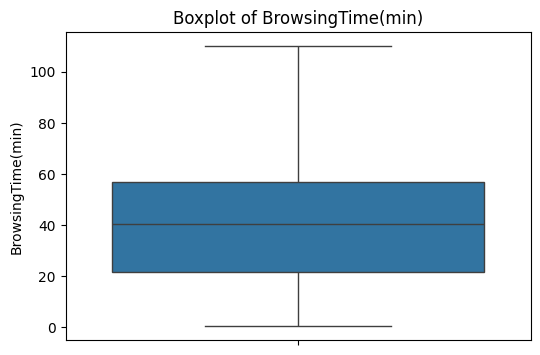

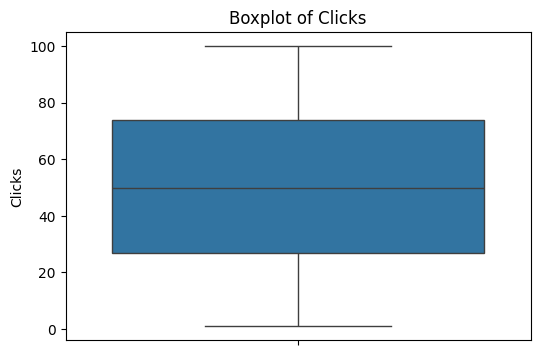

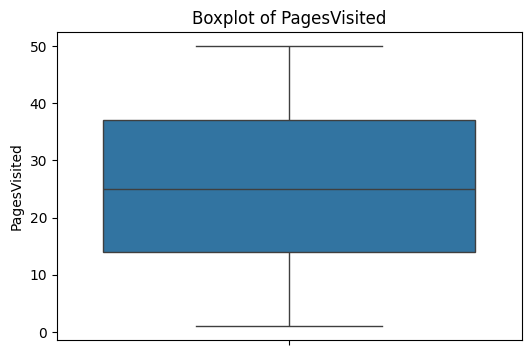

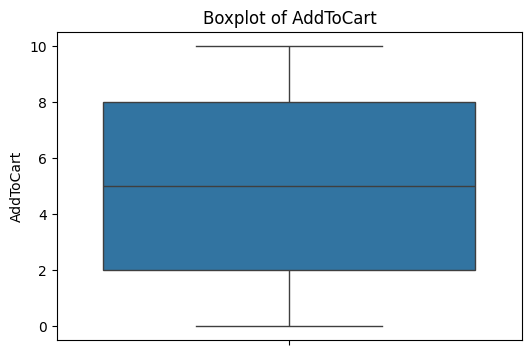

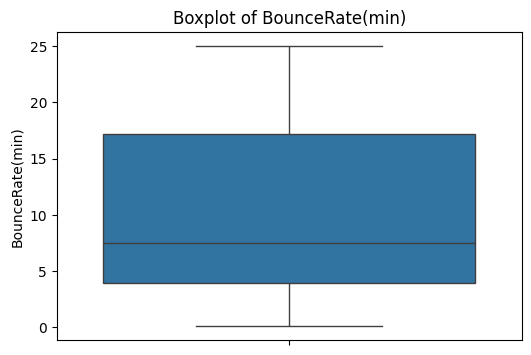

In [ ]:
# Boxplots for numerical columns before encoding
num_cols_original = X.select_dtypes(include=np.number).columns.tolist()

for col in num_cols_original:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=X[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()